<h1>Table of Contents<span class="tocSkip"></span></h1>
<div class="toc"><ul class="toc-item"></ul></div>

In [9]:
#Movies.csv
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [10]:
df = pd.read_csv('Movies.csv')

🔹 **Задание 1. Первичный анализ данных**

1. Загрузите файл в датафрейм и выведите первые 5 строк (Подсказка: найти в документации pandas, как читать csv файл, выставить разделителем запятую).
2. Первый столбец - индекс, который перезаписался как отдельный столбец: удалите его
3. Определите и выведите:

* количество строк и столбцов

* типы данных

* общую информацию по таблице и краткую статистику по числовым столбцам

* минимальное и максимальное значение по мировым сборам

* уникальные жанры

* количество фильмов по каждому рейтингу

In [11]:
df.drop(columns=['Unnamed: 0'], inplace=True)

In [16]:
print(df.head())
print(df.shape)
print(df.info())
print(df.describe())
print(df.columns)
print(df['World Sales (in $)'].max())
print(df['World Sales (in $)'].min())
print(df['Genre'].unique())
print(df['License'].value_counts())

                                               Title  \
0  Star Wars: Episode VII - The Force Awakens (2015)   
1                           Avengers: Endgame (2019)   
2                                      Avatar (2009)   
3                               Black Panther (2018)   
4                      Avengers: Infinity War (2018)   

                                          Movie Info  \
0  As a new threat to the galaxy rises, Rey, a de...   
1  After the devastating events of Avengers: Infi...   
2  A paraplegic Marine dispatched to the moon Pan...   
3  T'Challa, heir to the hidden but advanced king...   
4  The Avengers and their allies must be willing ...   

                           Distributor       Release Date  \
0  Walt Disney Studios Motion Pictures  December 16, 2015   
1  Walt Disney Studios Motion Pictures     April 24, 2019   
2                Twentieth Century Fox  December 16, 2009   
3  Walt Disney Studios Motion Pictures                NaN   
4  Walt Disney Studio

In [13]:
df.head()

,Title,Movie Info,Distributor,Release Date,Domestic Sales (in $),International Sales (in $),World Sales (in $),Genre,Movie Runtime,License
0,Star Wars: Episode VII - The Force Awakens (2015),"As a new threat to the galaxy rises, Rey, a de...",Walt Disney Studios Motion Pictures,"December 16, 2015",936662225,1132859475,2069521700,"['Action', 'Adventure', 'Sci-Fi']",2 hr 18 min,PG-13
1,Avengers: Endgame (2019),After the devastating events of Avengers: Infi...,Walt Disney Studios Motion Pictures,"April 24, 2019",858373000,1939128328,2797501328,"['Action', 'Adventure', 'Drama', 'Sci-Fi']",3 hr 1 min,PG-13
2,Avatar (2009),A paraplegic Marine dispatched to the moon Pan...,Twentieth Century Fox,"December 16, 2009",760507625,2086738578,2847246203,"['Action', 'Adventure', 'Fantasy', 'Sci-Fi']",2 hr 42 min,PG-13
3,Black Panther (2018),"T'Challa, heir to the hidden but advanced king...",Walt Disney Studios Motion Pictures,NaN,700426566,647171407,1347597973,"['Action', 'Adventure', 'Sci-Fi']",2 hr 14 min,NaN
4,Avengers: Infinity War (2018),The Avengers and their allies must be willing ...,Walt Disney Studios Motion Pictures,NaN,678815482,1369544272,2048359754,"['Action', 'Adventure', 'Sci-Fi']",2 hr 29 min,NaN


🔹 **Задание 2. Обработка пропусков и создание новых признаков**

1. Проверьте, в каких столбцах есть пропуски.
2. Замените пропуски в столбце с рейтингом на самое частотное значение (Подсказка: заменить на mode()[0]).
3. Удалите все строки с пропусками в дате релиза.
3. Добавьте новый столбец: доля домашних сборов относительно мировых.

In [20]:
df.isnull().sum()

Title                         0
Movie Info                    0
Distributor                   0
Release Date                  0
Domestic Sales (in $)         0
International Sales (in $)    0
World Sales (in $)            0
Genre                         0
Movie Runtime                 0
License                       0
dtype: int64

In [17]:
df['License'] = df['License'].fillna(df['License'].mode()[0])

In [19]:
df = df.dropna().reset_index(drop=True)

In [21]:
df['Share_of_Domestic_Sales'] = df['Domestic Sales (in $)'] / df['World Sales (in $)']

In [22]:
df.head()

,Title,Movie Info,Distributor,Release Date,Domestic Sales (in $),International Sales (in $),World Sales (in $),Genre,Movie Runtime,License,Share_of_Domestic_Sales
0,Star Wars: Episode VII - The Force Awakens (2015),"As a new threat to the galaxy rises, Rey, a de...",Walt Disney Studios Motion Pictures,"December 16, 2015",936662225,1132859475,2069521700,"['Action', 'Adventure', 'Sci-Fi']",2 hr 18 min,PG-13,0.452598
1,Avengers: Endgame (2019),After the devastating events of Avengers: Infi...,Walt Disney Studios Motion Pictures,"April 24, 2019",858373000,1939128328,2797501328,"['Action', 'Adventure', 'Drama', 'Sci-Fi']",3 hr 1 min,PG-13,0.306836
2,Avatar (2009),A paraplegic Marine dispatched to the moon Pan...,Twentieth Century Fox,"December 16, 2009",760507625,2086738578,2847246203,"['Action', 'Adventure', 'Fantasy', 'Sci-Fi']",2 hr 42 min,PG-13,0.267103
3,Titanic (1997),A seventeen-year-old aristocrat falls in love ...,Paramount Pictures,"December 19, 1997",659363944,1542283320,2201647264,"['Drama', 'Romance']",3 hr 14 min,PG-13,0.299487
4,Jurassic World (2015),"A new theme park, built on the original site o...",Universal Pictures,"June 10, 2015",652385625,1018130819,1670516444,"['Action', 'Adventure', 'Sci-Fi']",2 hr 4 min,PG-13,0.390529


🔹 **Задание 3. Работа с датами**

1. Преобразуйте столбец Release Date в тип datetime (Подсказка: найти в документации pandas, как вызывать функцию to_datetime).
2. Добавьте новый столбец Year, извлекая из даты только год (Подсказка: найти в документации pandas, как вызывать функцию dt.year).

In [23]:
df['Release Date'] = pd.to_datetime(df['Release Date'])

In [24]:
df['Year'] = df['Release Date'].dt.year

In [25]:
df.head()

,Title,Movie Info,Distributor,Release Date,Domestic Sales (in $),International Sales (in $),World Sales (in $),Genre,Movie Runtime,License,Share_of_Domestic_Sales,Year
0,Star Wars: Episode VII - The Force Awakens (2015),"As a new threat to the galaxy rises, Rey, a de...",Walt Disney Studios Motion Pictures,2015-12-16,936662225,1132859475,2069521700,"['Action', 'Adventure', 'Sci-Fi']",2 hr 18 min,PG-13,0.452598,2015
1,Avengers: Endgame (2019),After the devastating events of Avengers: Infi...,Walt Disney Studios Motion Pictures,2019-04-24,858373000,1939128328,2797501328,"['Action', 'Adventure', 'Drama', 'Sci-Fi']",3 hr 1 min,PG-13,0.306836,2019
2,Avatar (2009),A paraplegic Marine dispatched to the moon Pan...,Twentieth Century Fox,2009-12-16,760507625,2086738578,2847246203,"['Action', 'Adventure', 'Fantasy', 'Sci-Fi']",2 hr 42 min,PG-13,0.267103,2009
3,Titanic (1997),A seventeen-year-old aristocrat falls in love ...,Paramount Pictures,1997-12-19,659363944,1542283320,2201647264,"['Drama', 'Romance']",3 hr 14 min,PG-13,0.299487,1997
4,Jurassic World (2015),"A new theme park, built on the original site o...",Universal Pictures,2015-06-10,652385625,1018130819,1670516444,"['Action', 'Adventure', 'Sci-Fi']",2 hr 4 min,PG-13,0.390529,2015


🔹 **Задание 4. Фильтрация данных и срезы**

1. Найдите и выведите фильмы с 10 по 20 строку:

* с домашними сборами больше 70 миллионов (только столбцы с названиями фильмов и домашними сборами)

* со мстителями (в названии есть "Avengers") (только столбцы с названиями фильмов и описанием)

* 20-ого века и студии Paramount Pictures (только столбцы с названиями фильмов, годом и студией)

2. Отсортируйте и пересохраните таблицу в порядке убывания мировых сборов.

In [27]:
df.loc[10:20]

,Title,Movie Info,Distributor,Release Date,Domestic Sales (in $),International Sales (in $),World Sales (in $),Genre,Movie Runtime,License,Share_of_Domestic_Sales,Year
10,Star Wars: Episode IX - The Rise of Skywalker ...,In the riveting conclusion of the landmark Sky...,Walt Disney Studios Motion Pictures,2019-12-18,515202542,558946737,1074149279,"['Action', 'Adventure', 'Fantasy', 'Sci-Fi']",2 hr 21 min,PG-13,0.479638,2019
11,Beauty and the Beast (2017),A selfish Prince is cursed to become a monster...,Walt Disney Studios Motion Pictures,2017-03-16,504481165,769095055,1273576220,"['Adventure', 'Family', 'Fantasy', 'Musical', ...",2 hr 9 min,PG,0.396114,2017
12,Frozen II (2019),"Anna, Elsa, Kristoff, Olaf and Sven leave Aren...",Walt Disney Studios Motion Pictures,2019-11-20,477373578,972653355,1450026933,"['Adventure', 'Animation', 'Comedy', 'Family',...",1 hr 43 min,PG,0.329217,2019
13,Star Wars: Episode I - The Phantom Menace (1999),Two Jedi escape a hostile blockade to find all...,Twentieth Century Fox,1999-05-19,474544677,552538030,1027082707,"['Action', 'Adventure', 'Fantasy', 'Sci-Fi']",2 hr 16 min,PG,0.462032,1999
14,Star Wars: Episode IV - A New Hope (1977),Luke Skywalker joins forces with a Jedi Knight...,Twentieth Century Fox,1977-05-25,460998507,195751992,775398007,"['Action', 'Adventure', 'Fantasy', 'Sci-Fi']",2 hr 1 min,PG,0.594531,1977
15,Avengers: Age of Ultron (2015),When Tony Stark and Bruce Banner try to jump-s...,Walt Disney Studios Motion Pictures,2015-04-22,459005868,943803672,1402809540,"['Action', 'Adventure', 'Sci-Fi']",2 hr 21 min,PG-13,0.327205,2015
16,The Dark Knight Rises (2012),Eight years after the Joker's reign of anarchy...,Warner Bros.,2012-07-19,448139099,633003513,1081142612,"['Action', 'Crime', 'Drama']",2 hr 44 min,PG-13,0.414505,2012
17,Shrek 2 (2004),Shrek and Fiona travel to the Kingdom of Far F...,DreamWorks Distribution,2004-05-19,441226247,487534523,928760770,"['Adventure', 'Animation', 'Comedy', 'Family',...",1 hr 33 min,PG,0.475070,2004
18,E.T. the Extra-Terrestrial (1982),A troubled child summons the courage to help a...,Universal Pictures,1982-06-11,435110554,304203888,792910554,"['Adventure', 'Family', 'Sci-Fi']",1 hr 55 min,PG,0.548751,1982
19,Toy Story 4 (2019),"When a new toy called ""Forky"" joins Woody and ...",Walt Disney Studios Motion Pictures,2019-06-20,434038008,639356585,1073394593,"['Adventure', 'Animation', 'Comedy', 'Family',...",1 hr 40 min,G,0.404360,2019


In [29]:
df[df['Domestic Sales (in $)'] > 70000000][['Title', 'Domestic Sales (in $)']]

,Title,Domestic Sales (in $)
0,Star Wars: Episode VII - The Force Awakens (2015),936662225
1,Avengers: Endgame (2019),858373000
2,Avatar (2009),760507625
3,Titanic (1997),659363944
4,Jurassic World (2015),652385625
...,...,...
795,The Notebook (2004),81001787
796,Jimmy Neutron: Boy Genius (2001),80936232
797,Eat Pray Love (2010),80574010
798,The Texas Chainsaw Massacre (2003),80571655


In [30]:
df[df['Title'].str.contains('Avengers', case=False, na=False)][['Title', 'Movie Info']]

,Title,Movie Info
1,Avengers: Endgame (2019),After the devastating events of Avengers: Infi...
5,The Avengers (2012),Earth's mightiest heroes must come together an...
15,Avengers: Age of Ultron (2015),When Tony Stark and Bruce Banner try to jump-s...


In [31]:
df[(df['Year'] >= 1901) & (df['Year'] <= 2000) &
              (df['Distributor'].str.contains('Paramount Pictures', case=False, na=False))][['Title', 'Year', 'Distributor']]

,Title,Year,Distributor
3,Titanic (1997),1997,Paramount Pictures
59,Forrest Gump (1994),1994,Paramount Pictures
118,Indiana Jones and the Raiders of the Lost Ark ...,1981,Paramount Pictures
155,Ghost (1990),1990,Paramount Pictures
164,Mission: Impossible II (2000),2000,Paramount Pictures
198,Indiana Jones and the Last Crusade (1989),1989,Paramount Pictures
208,Grease (1978),1978,Paramount Pictures
224,What Women Want (2000),2000,Paramount Pictures
229,Mission: Impossible (1996),1996,Paramount Pictures
234,Indiana Jones and the Temple of Doom (1984),1984,Paramount Pictures


In [33]:
df = df.sort_values(by='World Sales (in $)', ascending=False)

In [34]:
df.head()

,Title,Movie Info,Distributor,Release Date,Domestic Sales (in $),International Sales (in $),World Sales (in $),Genre,Movie Runtime,License,Share_of_Domestic_Sales,Year
2,Avatar (2009),A paraplegic Marine dispatched to the moon Pan...,Twentieth Century Fox,2009-12-16,760507625,2086738578,2847246203,"['Action', 'Adventure', 'Fantasy', 'Sci-Fi']",2 hr 42 min,PG-13,0.267103,2009
1,Avengers: Endgame (2019),After the devastating events of Avengers: Infi...,Walt Disney Studios Motion Pictures,2019-04-24,858373000,1939128328,2797501328,"['Action', 'Adventure', 'Drama', 'Sci-Fi']",3 hr 1 min,PG-13,0.306836,2019
3,Titanic (1997),A seventeen-year-old aristocrat falls in love ...,Paramount Pictures,1997-12-19,659363944,1542283320,2201647264,"['Drama', 'Romance']",3 hr 14 min,PG-13,0.299487,1997
0,Star Wars: Episode VII - The Force Awakens (2015),"As a new threat to the galaxy rises, Rey, a de...",Walt Disney Studios Motion Pictures,2015-12-16,936662225,1132859475,2069521700,"['Action', 'Adventure', 'Sci-Fi']",2 hr 18 min,PG-13,0.452598,2015
4,Jurassic World (2015),"A new theme park, built on the original site o...",Universal Pictures,2015-06-10,652385625,1018130819,1670516444,"['Action', 'Adventure', 'Sci-Fi']",2 hr 4 min,PG-13,0.390529,2015


🔹 **Задание 5. Группировка, агрегация и визуализация**

1. Создайте таблицу с группировкой: сколько фильмов вышло в каждом году.
2. Постройте график по этим данным с:
* подписями осей
* названием графика
* сеткой

3. Создайте таблицу с двойной группировкой: сколько суммарно общемировых сборов собрала каждая студия, сколько фильмов каждая студия сняла.
4. Постройте сабплоты: две столбчатые диаграммы друг под другом по этим данным с:
* размером фигуры 12 * 12
* подписями осей
* названием графика
* цветовой палитрой
* повернутыми на 90 градусов лейблами на оси X
* перед выводом графика добавьте plt.tight_layot(), чтобы графики не накладывались друг на друга

In [44]:
df_distributors = df.groupby('Distributor').agg(number_movies=('Title', 'count'), world_sales=('World Sales (in $)', 'sum')).reset_index()
df_distributors.head()

,Distributor,number_movies,world_sales
0,Artisan Entertainment,1,248639099
1,Columbia Pictures,6,1288912626
2,Dimension Films,7,1223005113
3,DreamWorks,19,9917749677
4,DreamWorks Distribution,16,5272576107


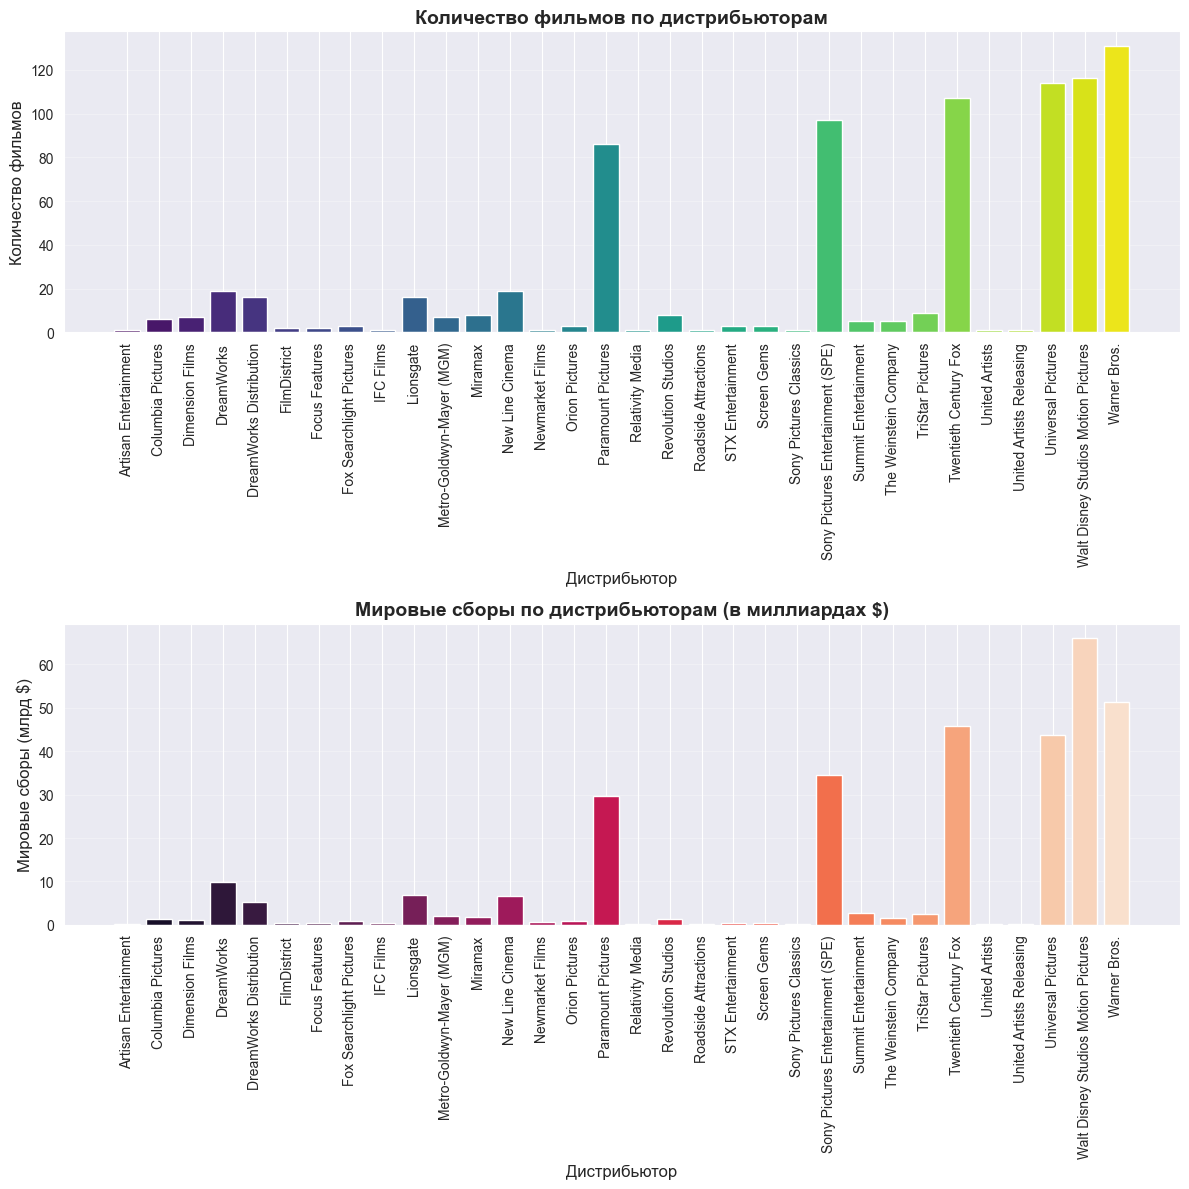

In [45]:
fig, axes = plt.subplots(2, 1, figsize=(12, 12))

bars1 = axes[0].bar(df_distributors['Distributor'],
                   df_distributors['number_movies'],
                   color=sns.color_palette('viridis', len(df_distributors)))
axes[0].set_title('Количество фильмов по дистрибьюторам', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Дистрибьютор', fontsize=12)
axes[0].set_ylabel('Количество фильмов', fontsize=12)
axes[0].tick_params(axis='x', rotation=90)
axes[0].grid(axis='y', alpha=0.3)

bars2 = axes[1].bar(df_distributors['Distributor'],
                   df_distributors['world_sales'] / 1e9,
                   color=sns.color_palette('rocket', len(df_distributors)))
axes[1].set_title('Мировые сборы по дистрибьюторам (в миллиардах $)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Дистрибьютор', fontsize=12)
axes[1].set_ylabel('Мировые сборы (млрд $)', fontsize=12)
axes[1].tick_params(axis='x', rotation=90)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()

plt.show()

In [41]:
df_movies = df.groupby('Year').size().reset_index(name='Movie Count')
df_movies.head()

,Year,Movie Count
0,1972,1
1,1975,1
2,1977,1
3,1978,2
4,1979,2


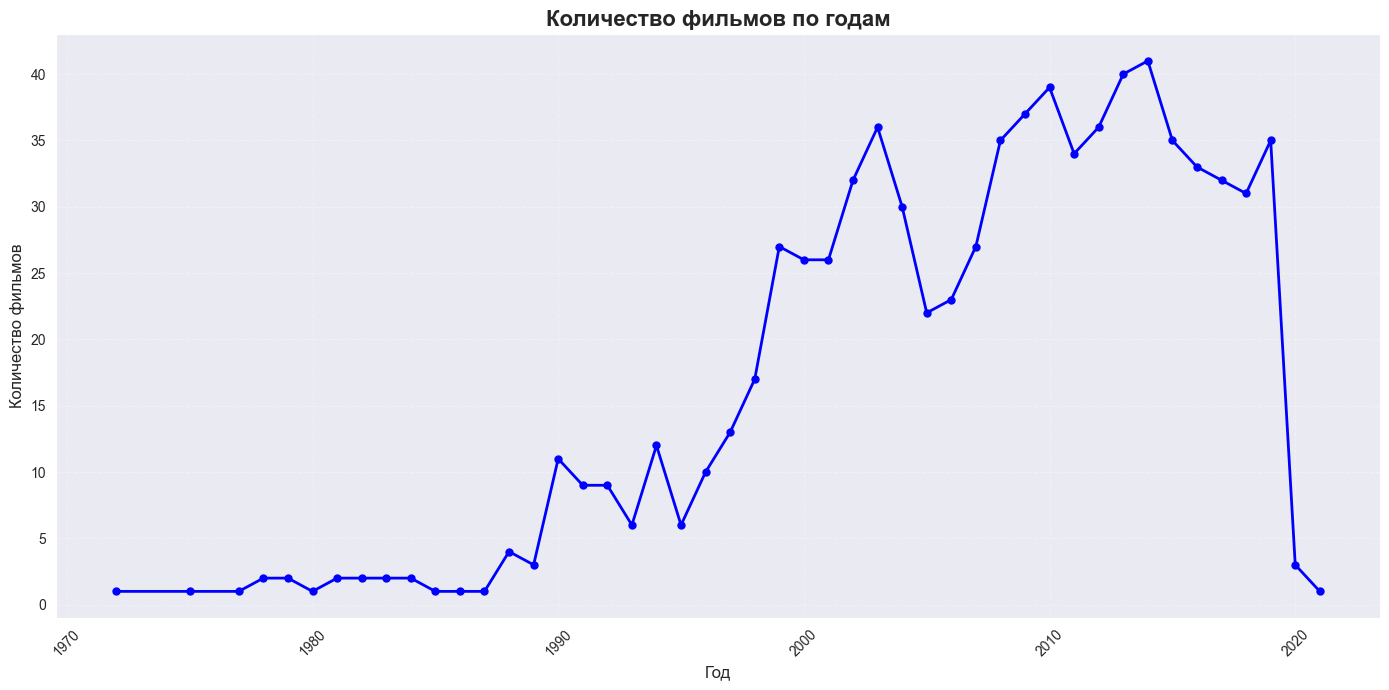

In [42]:
plt.figure(figsize=(14, 7))
plt.plot(df_movies['Year'], df_movies['Movie Count'],
         marker='o', linestyle='-', linewidth=2, markersize=5, color='blue')

plt.title('Количество фильмов по годам', fontsize=16, fontweight='bold')
plt.xlabel('Год', fontsize=12)
plt.ylabel('Количество фильмов', fontsize=12)
plt.grid(True, alpha=0.3, linestyle='--')
plt.xticks(rotation=45)

plt.tight_layout()

🔹 **Задание 6. Кастомные функции и применение apply()**

1. Напишите функцию movie_runtime_minutes, которая переведет длительность фильмов из текстового формата в минуты:
* как один из вариантов, можно найти оба числа, то есть часы и минуты, с помощью re.findall("[0-9]{1, }", x), не забыв импортировать библиотеку re
* сохранить это как список, затем умножить первое число (час) из списка на 60, прибавить второе число (минуты): не забыть учесть, что не во всех фильмах указаны минуты - значит, нужно прописать отдельные условия, если есть и часы, и минуты, или есть только часы
* не забыть, что элементы в списке - строковые, нужно перевести их в числа: условно будет int(numbers[0])*60 + ...
2. Примените функцию к таблице, создав новый столбец Movie Runtime Minutes.

In [46]:
import re

movie_runtime_minutes = lambda x: int(re.findall(r'\d+', x)[0])*60 + int(re.findall(r'\d+', x)[1]) if len(re.findall(r'\d+', x)) > 1 else int(re.findall(r'\d+', x)[0])*60

In [47]:
df['Movie Runtime Minutes'] = df['Movie Runtime'].apply(movie_runtime_minutes)

In [48]:
df.head()

,Title,Movie Info,Distributor,Release Date,Domestic Sales (in $),International Sales (in $),World Sales (in $),Genre,Movie Runtime,License,Share_of_Domestic_Sales,Year,Movie Runtime Minutes
2,Avatar (2009),A paraplegic Marine dispatched to the moon Pan...,Twentieth Century Fox,2009-12-16,760507625,2086738578,2847246203,"['Action', 'Adventure', 'Fantasy', 'Sci-Fi']",2 hr 42 min,PG-13,0.267103,2009,162
1,Avengers: Endgame (2019),After the devastating events of Avengers: Infi...,Walt Disney Studios Motion Pictures,2019-04-24,858373000,1939128328,2797501328,"['Action', 'Adventure', 'Drama', 'Sci-Fi']",3 hr 1 min,PG-13,0.306836,2019,181
3,Titanic (1997),A seventeen-year-old aristocrat falls in love ...,Paramount Pictures,1997-12-19,659363944,1542283320,2201647264,"['Drama', 'Romance']",3 hr 14 min,PG-13,0.299487,1997,194
0,Star Wars: Episode VII - The Force Awakens (2015),"As a new threat to the galaxy rises, Rey, a de...",Walt Disney Studios Motion Pictures,2015-12-16,936662225,1132859475,2069521700,"['Action', 'Adventure', 'Sci-Fi']",2 hr 18 min,PG-13,0.452598,2015,138
4,Jurassic World (2015),"A new theme park, built on the original site o...",Universal Pictures,2015-06-10,652385625,1018130819,1670516444,"['Action', 'Adventure', 'Sci-Fi']",2 hr 4 min,PG-13,0.390529,2015,124


🔹 **Задание 7. Визуализация корреляций**

1. Выведите корреляционную матрицу по числовым признакам в таблице.
2. Постройте тепловую карту по этим данным с названием графика.
3. Напишите в отдельной ячейке markdown, есть ли взаимосвязь между продолжительностью фильма и его сборами?
4. Постройте диаграмму рассеяния между признаками, у которых наибольшая корреляция (Подсказка: в документации найдите matplotlib scatter, какие обязательные параметры туда нужно передать).
5. Сохраните итоговую таблицу в excel.

In [55]:
corr_matrix = df.corr(numeric_only=True)

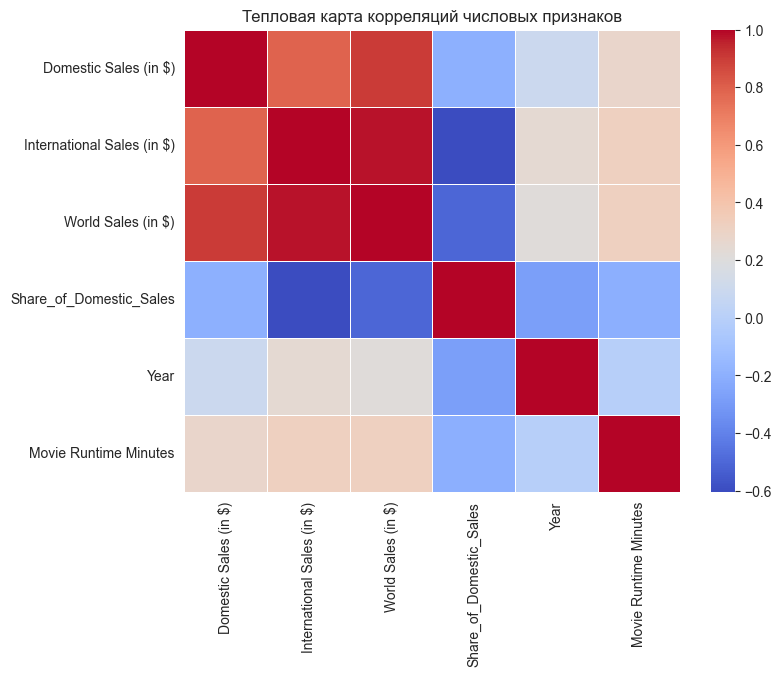

In [50]:
plt.figure(figsize=(8,6))
sns.heatmap(
    df.corr(numeric_only=True),
    cmap="coolwarm",
    linewidths=0.5,
)
plt.title("Тепловая карта корреляций числовых признаков", fontsize=12)
plt.show()

# Взаимосвязь между продолжительностью фильма и его сборами есть, но слабая (~0,3)

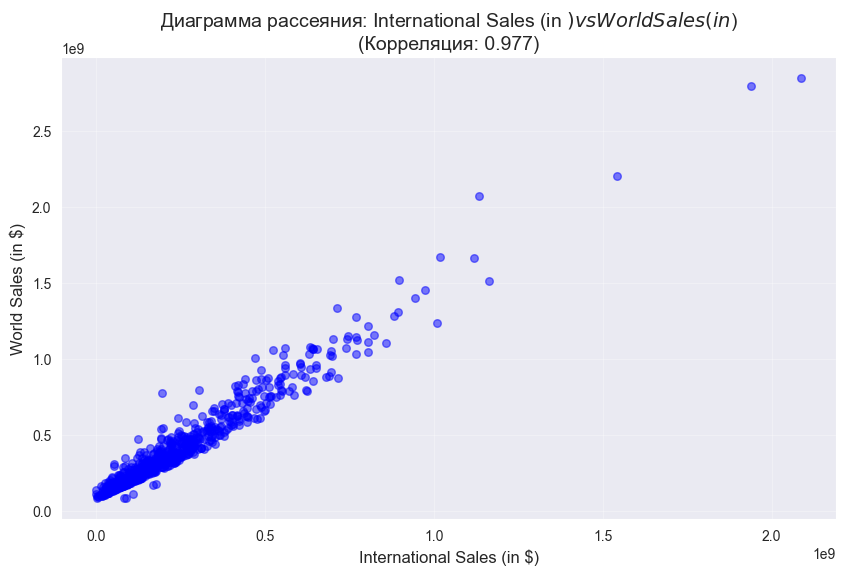

In [56]:
np.fill_diagonal(corr_matrix.values, 0)
max_corr = corr_matrix.stack().abs().max()
max_corr_pair = corr_matrix.stack().abs().idxmax()

plt.figure(figsize=(10, 6))
plt.scatter(df[max_corr_pair[0]], df[max_corr_pair[1]],
           alpha=0.5, color='blue', s=30)

plt.title(f'Диаграмма рассеяния: {max_corr_pair[0]} vs {max_corr_pair[1]}\n(Корреляция: {max_corr:.3f})', fontsize=14)
plt.xlabel(max_corr_pair[0], fontsize=12)
plt.ylabel(max_corr_pair[1], fontsize=12)
plt.grid(True, alpha=0.3)

plt.show()

In [60]:
df.to_excel("Обработанные данные.xlsx", index=False)